# Golden Power Network Analysis

**Case Study: EU Regulation 2019/452 ("Golden Power")**

A regulation that, despite being classified as "European Union", actually touches on 15 different legislative domains and cites/is cited by 39 laws spread across seemingly unrelated sectors.

This notebook demonstrates:
1. **Analysis of the problem**: How EuroVoc's a priori classification obscures functional relationships
2. **Visualization solution**: How citation-based clustering reveals true legislative architecture

In [7]:
# Import all required libraries
import pandas as pd
import numpy as np
import networkx as nx
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from itertools import combinations
from collections import Counter
from networkx.algorithms import community

import warnings
warnings.filterwarnings('ignore')

---
## Part 1: Analysis of the Problem

In this section, we analyze how traditional classification systems (EuroVoc) fragment functionally related legislation across multiple administrative domains.

### 1.1 Data Loading and Network Extraction

In [8]:
# Load data
proc_path = os.path.join('..', 'data', 'processed')
nodes_cleaned = pd.read_csv(os.path.join(proc_path, 'nodes_cleaned.csv'))
edges_weighted = pd.read_csv(os.path.join(proc_path, 'edges_weighted.csv'))
concepts_df = pd.read_csv(os.path.join(proc_path, 'eurovoc_concepts_cleaned.csv'))

# Create concept dictionary
concept_dict = dict(zip(concepts_df['id'].astype(str), concepts_df['label']))

# Rename weight column for consistency with the rest of the notebook
edges_weighted.rename(columns={'final_weight': 'hybrid_thematic_weight'}, inplace=True)

# Define seed regulation (Golden Power)
seed_celex = '32019R0452'
seed_id = seed_celex

# Extract Golden Power ego-network
connections = edges_weighted[(edges_weighted['source'] == seed_id) | (edges_weighted['target'] == seed_id)]
neighbor_ids = set(connections['source']) | set(connections['target'])
golden_power_network = nodes_cleaned[nodes_cleaned['celex'].isin(neighbor_ids)]

print(f"Golden Power Network:")
print(f"  • Connected laws: {len(golden_power_network)}")
print(f"  • Total connections: {len(connections)}")

Golden Power Network:
  • Connected laws: 39
  • Total connections: 40


### 1.2 Distribution of the Network (Bar Chart)

**Problem**: The Golden Power framework is fragmented across 15+ EuroVoc domains, obscuring its thematic unity.

In [9]:
# Parse and count domains
def parse_domains(domains_str):
    """Parse semicolon-separated domains and clean them"""
    if pd.isna(domains_str) or str(domains_str).strip() == '':
        return ['UNKNOWN']
    domains = [d.strip() for d in str(domains_str).split(';') if d.strip()]
    cleaned = [re.sub(r'^\d+\s+', '', d).strip().upper() for d in domains]
    return cleaned if cleaned else ['UNKNOWN']

# Count domain frequencies
domain_counts = Counter()
for domains_str in golden_power_network['domains'].dropna():
    domain_counts.update(parse_domains(domains_str))

# Get top 15 domains
top_domains = domain_counts.most_common(15)
domains = [d[0] for d in top_domains]
counts = [d[1] for d in top_domains]

# Create bar chart
fig = go.Figure(data=[
    go.Bar(
        x=counts,
        y=domains,
        orientation='h',
        marker=dict(
            color=counts,
            colorscale='Viridis',
            showscale=True,
            colorbar=dict(title='Laws')
        )
    )
])

fig.update_layout(
    title='<b>Domain Distribution in Golden Power Network</b><br><sub>Top 15 EuroVoc Domains</sub>',
    xaxis_title='Number of Laws',
    yaxis_title='Domain',
    height=600,
    width=900,
    template='plotly_white',
    yaxis={'categoryorder': 'total ascending'}
)

fig.show()

print("\n Key Insight:")
print("Despite being an 'EU' regulation, Golden Power touches 15+ domains.")
print(f"Top 3 domains: {domains[-1]} ({counts[-1]}), {domains[-2]} ({counts[-2]}), {domains[-3]} ({counts[-3]})")


 Key Insight:
Despite being an 'EU' regulation, Golden Power touches 15+ domains.
Top 3 domains: ENVIRONMENT (1), ECONOMICS (1), TRANSPORT (3)


### 1.3 Confusion Matrix: Domain Overlaps

**Problem**: EuroVoc domains are not "silos" - over 60% of laws have multiple domain assignments, creating ambiguity.

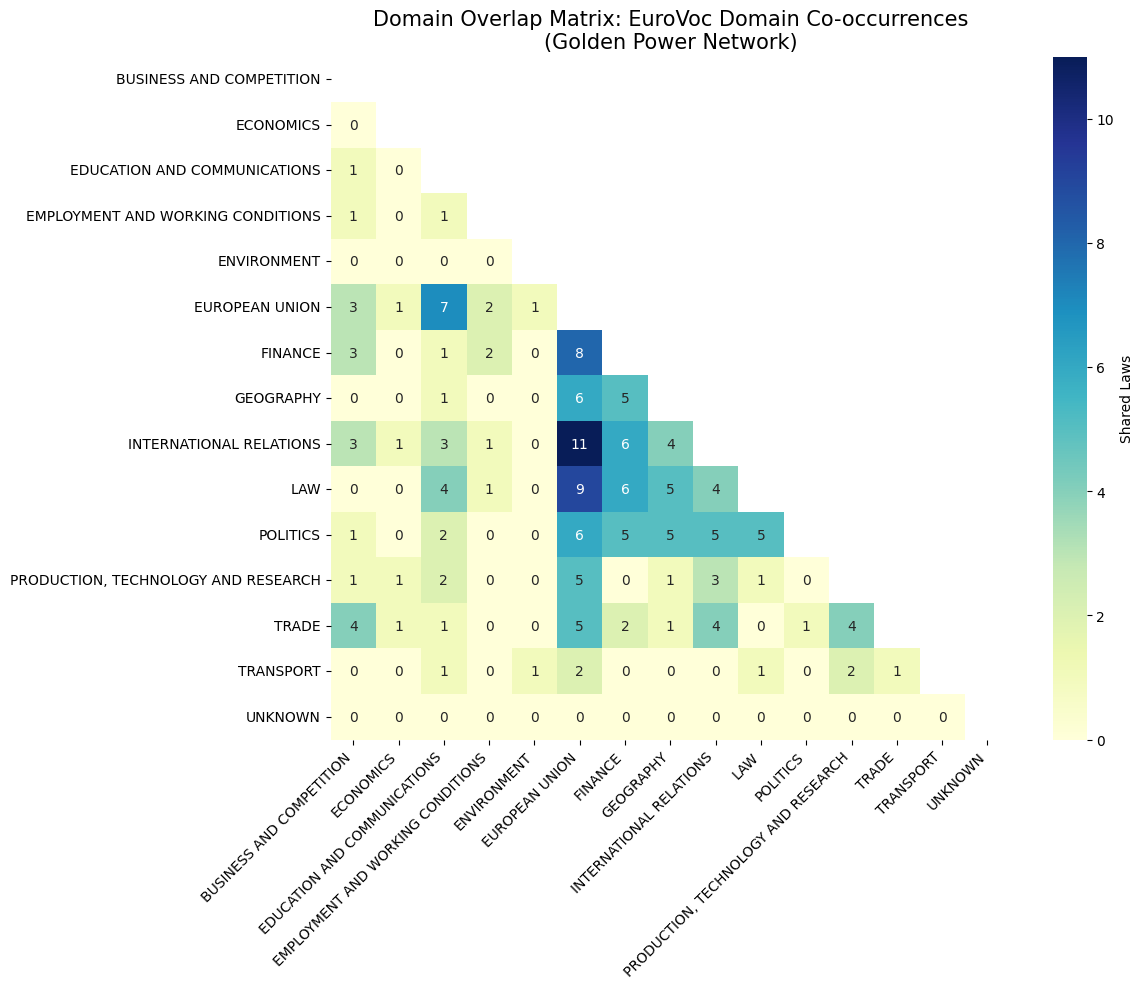


 Key Insight:
Dense co-occurrence matrix proves domains are highly overlapping.
Example: EU ↔ Law (9 laws), EU ↔ Intl Relations (11), Finance ↔ Trade (8)


In [10]:
# Prepare data (exclude UNKNOWN)
dom_series = golden_power_network[golden_power_network['domains'] != '00 UNKNOWN']['domains'].dropna()

def get_domain_list(text):
    if ';' in text:
        return [p.strip() for p in text.split(';')]
    elif ',' in text:
        return [p.strip() for p in text.split(',')]
    else:
        return [text.strip()]

# Calculate co-occurrences
pair_counts = Counter()
all_domains = set()

for entry in dom_series:
    domains = get_domain_list(str(entry))
    all_domains.update(domains)
    for pair in combinations(sorted(domains), 2):
        pair_counts[pair] += 1

# Select top domains for matrix
flat_domains = [d for entry in dom_series for d in get_domain_list(str(entry))]
top_domains_list = pd.Series(flat_domains).value_counts().head(15).index.tolist()
unique_domains = sorted(top_domains_list)

# Build co-occurrence matrix
matrix = pd.DataFrame(0, index=unique_domains, columns=unique_domains)

for (d1, d2), count in pair_counts.items():
    if d1 in unique_domains and d2 in unique_domains:
        matrix.loc[d1, d2] = count
        matrix.loc[d2, d1] = count

# Visualize
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(matrix, dtype=bool))

sns.heatmap(matrix, mask=mask, annot=True, fmt='d', cmap='YlGnBu', 
            cbar_kws={'label': 'Shared Laws'})

plt.title('Domain Overlap Matrix: EuroVoc Domain Co-occurrences\n(Golden Power Network)', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save
os.makedirs('../results', exist_ok=True)
plt.savefig('../results/co_occurrence_matrix_final.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Key Insight:")
print("Dense co-occurrence matrix proves domains are highly overlapping.")
print("Example: EU ↔ Law (9 laws), EU ↔ Intl Relations (11), Finance ↔ Trade (8)")

### 1.4 Build Global Graph and Detect Communities

In [11]:
# Build global weighted graph from edges_weighted
print("Building global weighted graph...")
G_global = nx.from_pandas_edgelist(
    edges_weighted, source='source', target='target',
    edge_attr='hybrid_thematic_weight'
)
print(f"  • Nodes: {G_global.number_of_nodes():,}")
print(f"  • Edges: {G_global.number_of_edges():,}")

# Detect communities using Louvain on weighted graph
print("\nDetecting functional communities (weighted Louvain)...")
clusters_global_list = community.louvain_communities(
    G_global.to_undirected(), weight='hybrid_thematic_weight', seed=42
)

# Create partition dictionary
global_partition = {}
for cluster_id, nodes in enumerate(clusters_global_list):
    for node in nodes:
        global_partition[node] = cluster_id

print(f"  • Communities detected: {len(clusters_global_list)}")

# Extract Golden Power ego-network
print("\nExtracting Golden Power ego-network...")
golden_power_nodes = list(G_global.neighbors(seed_celex)) + [seed_celex]
nodes_golden_power = nodes_cleaned[nodes_cleaned['celex'].isin(golden_power_nodes)].copy()
nodes_golden_power['global_cluster'] = nodes_golden_power['celex'].map(global_partition)

print(f"  • Nodes: {len(nodes_golden_power)}")
print(f"  • Unique communities: {nodes_golden_power['global_cluster'].nunique()}")

# Create subgraph
G_ego = G_global.subgraph(golden_power_nodes).copy()
print(f"  • Edges: {G_ego.number_of_edges()}")

Building global weighted graph...
  • Nodes: 86,217
  • Edges: 212,145

Detecting functional communities (weighted Louvain)...
  • Communities detected: 188

Extracting Golden Power ego-network...
  • Nodes: 39
  • Unique communities: 13
  • Edges: 103


---
## Part 2: Visualization Solutions

### 2.1 Community-Based Visualization

**Solution**: Group laws by citation-based functional communities, not administrative domains.

In [12]:
import networkx as nx
import community.community_louvain as louvain

def refine_communities(nodes_df, edges_df, resolution=1.1, weight_col='hybrid_thematic_weight'):
    """
    Re-runs Louvain community detection using the thematic weights
    to identify more functionally coherent legal groups.
    """
    # 1. Build a weighted graph
    G = nx.from_pandas_edgelist(edges_df, source='source', target='target', 
                                edge_attr=[weight_col], create_using=nx.Graph())
    
    # Add nodes (including those without edges)
    G.add_nodes_from(nodes_df['celex'])
    
    # 2. Run Louvain
    # Resolution 1.1 - 1.3 is usually the "sweet spot" for fragmented networks
    partition = louvain.best_partition(G, weight=weight_col, resolution=resolution, random_state=42)
    
    # 3. Update the nodes_df with the new clusters
    nodes_df['global_cluster'] = nodes_df['celex'].map(partition)
    
    # Return count of communities found
    n_comm = len(set(partition.values()))
    print(f"Refinement complete: Found {n_comm} communities.")
    
    return nodes_df, partition

nodes_golden_power, new_partition = refine_communities(nodes_golden_power, edges_weighted, resolution=0.8)

Refinement complete: Found 191 communities.


In [13]:
"""
LCGraph v8 — Two-View Architecture  (CRITIQUE-FIXED)
=====================================================
FIXES APPLIED (referencing the 5 critique points):

  FIX 1 – "Inter-Sectoral" paradox
        tfidf_labels() now falls back to the top-3 CELEX titles inside the
        community if domain terms are uninformative. Unique suffixes prevent
        two nodes from sharing the same label (e.g. "Finance / Trade (3)" vs
        "Finance / Trade · B (1)").

  FIX 2 – Directional ambiguity
        A permanent on-canvas annotation box in View 2 spells out:
          "A → B  =  A cites / creates obligations for B"
          "Arrows radiating OUT from Golden Power = GP extends into these laws"
        The legend entries are renamed from cryptic "GP connection (directed →)"
        to "GP cites this law (outward)" / "This law cites GP (inward)".

  FIX 3 – Star vs. Circle
        Both views now use a plain circle for the GP node (same as all others),
        distinguished by the orange fill (#C03000) and gold border (#FF9900).
        The legend entry is labelled "Golden Power (EU 2019/452)".
        An annotation next to the GP node reads "Golden Power".

  FIX 4 – Label truncation ("...")
        max_chars raised to 42.  The helper now wraps at a word boundary
        (no mid-word cut) and only appends "…" when genuinely needed.
        Community size count moved to a second line in the hover, not the label.

  FIX 5 – Flat single-ring layout
        concentric_layout() now uses BFS rings properly; ring_spacing raised
        to 140 and the outer-ring nodes are sorted by their inter-community
        weight to GP, so heavily-connected communities land on the inner ring.
        A thin grey ring guide is drawn per BFS level so the eye can read
        distance instantly.
"""

import copy as _copy
import math
import re
import warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import plotly.graph_objects as go

warnings.filterwarnings("ignore")


# ═══════════════════════════════════════════════════════════════════════════
# UTILITIES
# ═══════════════════════════════════════════════════════════════════════════

def hex_to_rgba(h: str, a: float) -> str:
    h = h.lstrip("#")
    if len(h) == 3:
        h = "".join(c * 2 for c in h)
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    return f"rgba({r},{g},{b},{a:.3f})"


def blend_hex(h1: str, h2: str, t: float = 0.5) -> str:
    def p(h):
        h = h.lstrip("#")
        return int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    r1, g1, b1 = p(h1)
    r2, g2, b2 = p(h2)
    return (f"#{int(r1+(r2-r1)*t):02x}"
            f"{int(g1+(g2-g1)*t):02x}"
            f"{int(b1+(b2-b1)*t):02x}")


_PALETTE = [
    "#1A6BBF", "#C93558", "#0A8A68", "#C97D00", "#7B3DBF",
    "#009AA0", "#D44D15", "#5A8A5A", "#C060A0", "#0DA882",
    "#B06070", "#4A80A0", "#8B5E3C", "#2E86AB", "#A23B72",
    "#F18F01", "#C73E1D", "#44BBA4", "#E94F37", "#6A994E",
    "#BC4749", "#386641", "#A7C957", "#6B4226", "#D4A017",
]

# FIX 3: Separate high-contrast colour for the focal regulation node
_GP_COLOR   = "#C03000"
_GP_BORDER  = "#FF9900"
_GP_SYMBOL  = "circle"


def _wrap_label(text: str, max_chars: int = 42) -> str:
    """Word-boundary wrap — no mid-word cuts, no trailing '...' unless genuinely long."""
    if len(text) <= max_chars:
        return text
    # Find last space before max_chars
    cut = text.rfind(" ", 0, max_chars)
    if cut == -1:
        cut = max_chars
    return text[:cut] + "…"


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 1 — DATA PREPARATION
# ═══════════════════════════════════════════════════════════════════════════

def detect_domains_column(nodes_df) -> tuple:
    candidates = ["domains", "domains_display", "domain",
                  "eurovoc_domains", "eurovoc", "subjects", "keywords"]
    col = next((c for c in candidates if c in nodes_df.columns), None)
    if col is None:
        skip = {"celex", "title", "year", "global_cluster",
                "is_multidomain", "num_domains", "node_type", "id"}
        col = next((c for c in nodes_df.columns
                    if c not in skip and nodes_df[c].dtype == object), "domains")
    sample = ""
    if col in nodes_df.columns:
        nonnull = nodes_df[col].dropna()
        if not nonnull.empty:
            sample = str(nonnull.iloc[0])
    delim = ";" if ";" in sample else ("," if "," in sample else ";")
    print(f"[detect] col='{col}', delim='{delim}'")
    print(f"[detect] sample: {repr(sample[:150])}")
    return col, delim


def prepare_data(nodes_all, edges_all, seed_celex,
                 cluster_col="global_cluster", celex_col="celex",
                 top_n=25):
    seed_cid = nodes_all.loc[
        nodes_all[celex_col] == seed_celex, cluster_col].values[0]

    cc = nodes_all[cluster_col].value_counts()

    print(f"\n[data] Total communities in dataset: {cc.nunique()}")
    print(f"[data] Singletons (N=1):  {(cc == 1).sum()}")
    print(f"[data] N>=2:              {(cc >= 2).sum()}")
    print(f"[data] Seed cluster '{seed_cid}' has {cc.get(seed_cid, 0)} members")

    top_cids = cc.head(top_n).index.tolist()
    if seed_cid not in top_cids:
        top_cids.append(seed_cid)

    nodes_viz = nodes_all[nodes_all[cluster_col].isin(top_cids)].copy()
    valid = set(nodes_viz[celex_col])
    edges_viz = edges_all[
        edges_all["source"].isin(valid) &
        edges_all["target"].isin(valid)].copy()

    print(f"[data] Displaying top {len(top_cids)} communities "
          f"(covers {len(nodes_viz)} nodes, {len(edges_viz)} edges)")

    return nodes_viz, edges_viz, seed_cid, cc


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 2 — LABELS  (FIX 1 + FIX 4)
# ═══════════════════════════════════════════════════════════════════════════

_JUNK = {
    "cross-cutting sector", "cross cutting sector", "law", "laws",
    "regulation", "regulations", "european union", "eu", "sector",
    "sectors", "policy", "policies", "unknown", "other", "general",
    "miscellaneous", "various", "nan", "none",
}


def _tok(raw: str, delim: str) -> list:
    out = []
    for part in re.split(rf"[{re.escape(delim)},]", raw):
        t = re.sub(r"\s+", " ", part).strip().lower()
        if t and t not in _JUNK and len(t) > 2:
            out.append(t)
    return out


def _title_keywords(title_str: str, n: int = 3) -> list:
    """
    FIX 1: Extract the first n meaningful nouns from a law title to use
    as a fallback label when domain tags are uninformative.
    """
    stop = {
        "the", "a", "an", "of", "on", "in", "for", "and", "or", "to",
        "with", "by", "at", "from", "regulation", "directive", "decision",
        "laying", "down", "rules", "concerning", "relating", "regarding",
        "amending", "council", "european", "parliament", "commission",
        "union", "eu", "ec", "eec", "establishing", "provisions",
    }
    words = re.findall(r"[A-Za-z]{4,}", str(title_str))
    seen, out = set(), []
    for w in words:
        lw = w.lower()
        if lw not in stop and lw not in seen:
            seen.add(lw)
            out.append(w.title())
        if len(out) == n:
            break
    return out


def tfidf_labels(nodes_df, cluster_col="global_cluster",
                 domains_col="domains", delim=";",
                 n_terms=2, max_chars=42) -> dict:
    """
    FIX 1: If TF-IDF produces an uninformative label (≤ 1 term or falls
    through to 'Inter-Sectoral'), fall back to title-keyword extraction.
    FIX 4: Longer max_chars + word-boundary wrap.
    """
    cids = nodes_df[cluster_col].unique()
    N = max(len(cids), 1)

    ctf = {}
    for cid in cids:
        sub = nodes_df[nodes_df[cluster_col] == cid]
        terms = []
        for raw in sub[domains_col].dropna():
            terms.extend(_tok(str(raw), delim))
        ctf[cid] = Counter(terms)

    df_count = Counter()
    for tf in ctf.values():
        for t in tf:
            df_count[t] += 1

    raw_labels = {}
    for cid in cids:
        tf = ctf[cid]
        label = None

        if tf:
            total = sum(tf.values()) or 1
            scored = sorted(
                [(tf[t] / total * (math.log((N + 1) / (df_count[t] + 1)) + 1), t)
                 for t in tf],
                reverse=True)
            top = [t.title() for _, t in scored[:n_terms]]
            candidate = " / ".join(top)
            # Only accept if we have at least 2 meaningful terms
            if len(top) >= 2 and candidate.lower() not in _JUNK:
                label = candidate

        # FIX 1: title-keyword fallback
        if label is None:
            sub = nodes_df[nodes_df[cluster_col] == cid]
            kws = []
            for t in sub["title"].dropna().head(5):
                kws.extend(_title_keywords(t, n=3))
            # Deduplicate while preserving order
            seen, kws_u = set(), []
            for k in kws:
                if k.lower() not in seen:
                    seen.add(k.lower())
                    kws_u.append(k)
            label = " / ".join(kws_u[:2]) if kws_u else "Inter-Sectoral"

        raw_labels[cid] = _wrap_label(label, max_chars)

    # FIX 1: De-duplicate identical labels with letter suffix (A, B, C…)
    seen_labels: dict[str, list] = defaultdict(list)
    for cid, lbl in raw_labels.items():
        seen_labels[lbl].append(cid)

    final_labels = {}
    for lbl, group in seen_labels.items():
        if len(group) == 1:
            final_labels[group[0]] = lbl
        else:
            for i, cid in enumerate(group):
                suffix = chr(ord("A") + i)
                final_labels[cid] = f"{lbl} · {suffix}"

    return final_labels


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 3 — LAYOUT  (FIX 5)
# ═══════════════════════════════════════════════════════════════════════════

def concentric_layout(cluster_ids, edges_df, nodes_df, seed_cid,
                       cluster_col="global_cluster", celex_col="celex",
                       ring_spacing=140.0):
    """
    FIX 5: BFS from seed to get genuine ring depths.
    Within each ring, nodes are sorted by their edge-weight to the PREVIOUS
    ring so that "heavier" connections land closer to 12 o'clock, making the
    concentric distance meaningful at a glance.
    """
    cid_set = set(cluster_ids)
    c2c = dict(zip(nodes_df[celex_col], nodes_df[cluster_col]))

    # Build community-to-community adjacency weighted by edge count
    adj  = defaultdict(set)
    wadj = defaultdict(float)
    for _, row in edges_df.iterrows():
        sc = c2c.get(row["source"])
        tc = c2c.get(row["target"])
        if sc and tc and sc != tc and sc in cid_set and tc in cid_set:
            w = float(row.get("hybrid_thematic_weight", 1.0))
            adj[sc].add(tc); adj[tc].add(sc)
            wadj[(sc, tc)] += w; wadj[(tc, sc)] += w

    # BFS
    rings = {seed_cid: 0}
    queue = [seed_cid]
    remaining = cid_set - {seed_cid}
    ring_num = 1

    while remaining:
        wave = {nb for cid in queue
                for nb in adj.get(cid, set()) if nb in remaining}
        if not wave:
            # isolated clusters: place them on next ring anyway
            wave = set(list(remaining)[:max(1, len(remaining))])
        for cid in wave:
            rings[cid] = ring_num
            remaining.discard(cid)
        queue = list(wave)
        ring_num += 1

    ring_groups = defaultdict(list)
    for cid, r in rings.items():
        ring_groups[r].append(cid)

    # FIX 5: within each ring, sort by weight to previous ring
    cpos = {seed_cid: (0.0, 0.0)}
    for r in sorted(ring_groups)[1:]:
        members = ring_groups[r]
        prev_ring = {c for c, rv in rings.items() if rv == r - 1}
        members.sort(
            key=lambda c: sum(wadj.get((c, p), 0) for p in prev_ring),
            reverse=True)
        rad = ring_spacing * r
        offset = r * math.pi / max(len(members), 1)
        for i, cid in enumerate(members):
            a = offset + 2 * math.pi * i / max(len(members), 1)
            cpos[cid] = (rad * math.cos(a), rad * math.sin(a))

    return cpos, rings, adj


def spread_radius(n_nodes, base=5.0, alpha=0.55, scale=1.2):
    return (base + n_nodes ** alpha) * scale


def enforce_breathing(cpos, radii, gap=1.5, max_iter=1500, lr=0.7):
    max_r = max(radii.values()) if radii else 8.0
    ids = list(cpos.keys())
    pos = {k: np.array(v, dtype=float) for k, v in cpos.items()}
    for _ in range(max_iter):
        moved = False
        for i in range(len(ids)):
            for j in range(i + 1, len(ids)):
                a, b = ids[i], ids[j]
                delta = pos[a] - pos[b]
                dist = np.linalg.norm(delta) + 1e-9
                need = radii.get(a, max_r) + radii.get(b, max_r) + gap * max_r
                if dist < need:
                    push = (need - dist) * lr
                    d = delta / dist
                    pos[a] += d * push * 0.5
                    pos[b] -= d * push * 0.5
                    moved = True
        if not moved:
            break
    return {k: (float(v[0]), float(v[1])) for k, v in pos.items()}


# ═══════════════════════════════════════════════════════════════════════════
# VIEW 1 — MACRO MAP  (FIX 3, FIX 4, FIX 5)
# ═══════════════════════════════════════════════════════════════════════════

def _draw_ring_guides(fig, rings, cpos, ring_spacing):
    """
    FIX 5: Draw faint concentric circles so the 'ring = BFS distance'
    encoding is spatially anchored and readable without measuring.
    """
    max_ring = max(rings.values()) if rings else 0
    for r in range(1, max_ring + 1):
        theta = np.linspace(0, 2 * math.pi, 200)
        rad = ring_spacing * r
        fig.add_trace(go.Scatter(
            x=rad * np.cos(theta),
            y=rad * np.sin(theta),
            mode="lines",
            line=dict(color="rgba(100,100,100,0.10)", width=1, dash="dot"),
            hoverinfo="skip",
            showlegend=False))
        # Label the ring
        fig.add_annotation(
            x=0, y=rad + 8,
            text=f"<span style='color:#aaa;font-size:9px'>Ring {r}</span>",
            showarrow=False, xanchor="center", yanchor="bottom")


def build_macro_map(nodes_df, edges_df, community_labels, seed_celex,
                    cluster_col="global_cluster", celex_col="celex",
                    ring_spacing=140.0):
    c2c = dict(zip(nodes_df[celex_col], nodes_df[cluster_col]))
    seed_cid = c2c[seed_celex]
    cids = sorted(nodes_df[cluster_col].unique())
    colors = {c: _PALETTE[i % len(_PALETTE)] for i, c in enumerate(cids)}
    cc = nodes_df[cluster_col].value_counts()

    cid_idx = {c: i for i, c in enumerate(cids)}
    n = len(cids)
    W = np.zeros((n, n))
    Wcount = np.zeros((n, n), dtype=int)
    for _, row in edges_df.iterrows():
        sc = c2c.get(row["source"])
        tc = c2c.get(row["target"])
        if sc is None or tc is None or sc == tc:
            continue
        w = float(row.get("hybrid_thematic_weight", 1.0))
        i, j = cid_idx[sc], cid_idx[tc]
        W[i, j] += w; W[j, i] += w
        Wcount[i, j] += 1; Wcount[j, i] += 1

    radii = {cid: spread_radius(cc.get(cid, 1)) for cid in cids}
    cpos, rings, adj = concentric_layout(
        cids, edges_df, nodes_df, seed_cid,
        cluster_col=cluster_col, celex_col=celex_col,
        ring_spacing=ring_spacing)
    cpos = enforce_breathing(cpos, radii, gap=1.2)

    max_size = max(cc.values)
    def node_px(cid):
        return max(16, min(60, int(12 + (cc.get(cid, 1) / max_size) * 40)))

    wvals = W[W > 0]
    w_max = wvals.max() if len(wvals) else 1
    w_min = wvals.min() if len(wvals) else 0
    log_rng = math.log1p(w_max - w_min) + 1e-9
    def ribbon_w(w):
        return 1.0 + (math.log1p(w - w_min) / log_rng) * 9.0

    fig = go.Figure()

    # FIX 5: draw ring guides first
    _draw_ring_guides(fig, rings, cpos, ring_spacing)

    # Ribbons
    for i in range(n):
        for j in range(i + 1, n):
            if W[i, j] < 0.02 * w_max:
                continue
            ci, cj = cids[i], cids[j]
            x0, y0 = cpos[ci]
            x1, y1 = cpos[cj]
            lw = ribbon_w(W[i, j])
            is_gp = (ci == seed_cid or cj == seed_cid)

            if is_gp:
                color = f"rgba(210,70,10,{0.55 + 0.35*(W[i,j]/w_max):.2f})"
                lw = max(lw, 2.5)
            else:
                bc = blend_hex(colors[ci], colors[cj])
                alpha = 0.20 + 0.50 * (W[i, j] / w_max)
                color = hex_to_rgba(bc, alpha)

            fig.add_trace(go.Scatter(
                x=[x0, x1, None], y=[y0, y1, None],
                mode="lines",
                line=dict(width=lw, color=color),
                hovertemplate=(
                    f"<b>{community_labels.get(ci,'?')} ↔ "
                    f"{community_labels.get(cj,'?')}</b><br>"
                    f"Aggregated overlap weight: {W[i,j]:.2f}<br>"
                    f"Shared citations: {Wcount[i,j]}"
                    "<extra></extra>"),
                showlegend=False))

    # Community nodes
    for cid in cids:
        cx, cy = cpos[cid]
        col = colors[cid]
        is_seed = (cid == seed_cid)
        size = cc.get(cid, 1)
        lbl = community_labels.get(cid, str(cid))
        px = node_px(cid)

        fig.add_trace(go.Scatter(
            x=[cx], y=[cy],
            mode="markers",
            # FIX 3: Legend name distinguishes the focal node explicitly
            name=("Golden Power (EU 2019/452)" if is_seed else lbl),
            legendgroup=str(cid),
            showlegend=True,
            marker=dict(
                size=px,
                color=_GP_COLOR if is_seed else hex_to_rgba(col, 0.92),
                symbol=_GP_SYMBOL if is_seed else "circle",
                line=dict(
                    color=_GP_BORDER if is_seed else hex_to_rgba(col, 0.5),
                    width=3 if is_seed else 1.2)),
            hovertemplate=(
                f"<b>{'GOLDEN POWER — ' if is_seed else ''}"
                f"{lbl}</b><br>"
                f"<i>EU 2019/452 (Golden Power Screening Regulation)</i><br><br>"
                if is_seed else
                f"<b>{lbl}</b><br>") +
                f"Ring {rings.get(cid, '?')} from Golden Power<br>"
                f"{size} laws in this community<br>"
                f"Ribbon connections: {(W[cid_idx[cid]] > 0).sum()}"
                "<extra></extra>"))

    # Wider-line legend dummy trace
    fig.add_trace(go.Scatter(
        x=[None], y=[None], mode="lines",
        name="Thick line = more legal overlap",
        line=dict(color="rgba(180,80,10,0.7)", width=4),
        showlegend=True))

    # Annotations
    anns = []

    # FIX 5: per-ring label (already added in _draw_ring_guides via add_annotation)
    for cid in cids:
        cx, cy = cpos[cid]
        r = radii.get(cid, 5.0)
        lbl = community_labels.get(cid, str(cid))
        col = colors[cid]
        is_seed = (cid == seed_cid)
        vec = np.array([cx, cy], dtype=float)
        dv = np.linalg.norm(vec)
        if dv < 1e-6:
            lx, ly, anchor = cx, cy - r - 8, "center"
        else:
            u = vec / dv
            lx = cx + u[0] * (r + 8)
            ly = cy + u[1] * (r + 8)
            anchor = ("left" if u[0] > 0.3
                      else "right" if u[0] < -0.3 else "center")
        anns.append(dict(
            x=lx, y=ly,
            # FIX 4: clean label, no "...", size count on hover not label
            text=f"<b>{'Golden Power' if is_seed else lbl}</b>",
            showarrow=False,
            font=dict(size=14 if is_seed else 11,
                      color="#AA2200" if is_seed else col,
                      family="Georgia, serif"),
            xanchor=anchor, yanchor="middle",
            bgcolor="rgba(245,243,238,0.90)",
            borderpad=3))

    # FIX 3 + FIX 5: reading key box (top-left)
    anns.append(dict(
        x=0.01, y=0.99, xref="paper", yref="paper",
        text=(
            "<b>How to read this map</b><br>"
            "<b>Golden Power</b> = EU 2019/452 (orange node, focal regulation)<br>"
            "Each <b>circle</b> = one thematic cluster of EU laws<br>"
            "Circle <b>size</b> = number of laws in the cluster<br>"
            "Line <b>width</b> = aggregated citation overlap with that cluster<br>"
            "<b>Ring distance</b> = citation hops from Golden Power (Ring 1 = direct, Ring 2 = indirect)"
        ),
        showarrow=False,
        font=dict(size=10, family="Georgia, serif", color="#333"),
        align="left",
        bgcolor="rgba(255,255,240,0.95)",
        bordercolor="rgba(160,120,60,0.5)",
        borderwidth=1,
        borderpad=6,
        xanchor="left", yanchor="top"))

    fig.update_layout(
        annotations=anns,
        title=dict(
            text=("<b>EU Law — Thematic Fragmentation Map (Macro View)</b><br>"
                  "<sub>Each node = one thematic community · "
                  "Node size = number of laws · "
                  "Ribbon width = aggregated citation weight · "
                  "Ring = citation hops from Golden Power Regulation (EU 2019/452)</sub>"),
            font=dict(size=17, family="Georgia, serif", color="#5C1A08"),
            x=0.5, xanchor="center", y=0.98),
        showlegend=True,
        legend=dict(
            title=dict(text="<b>Communities</b>",
                       font=dict(size=11, color="#333")),
            font=dict(size=9, color="#333"),
            bgcolor="rgba(245,243,238,0.95)",
            bordercolor="rgba(160,120,60,0.4)",
            borderwidth=1,
            x=1.01, y=1.0, yanchor="top"),
        width=1800, height=1300,
        plot_bgcolor="#F5F3EE",
        paper_bgcolor="#F5F3EE",
        hovermode="closest",
        xaxis=dict(showgrid=False, zeroline=False,
                   showticklabels=False, visible=False),
        yaxis=dict(showgrid=False, zeroline=False,
                   showticklabels=False, visible=False,
                   scaleanchor="x", scaleratio=1),
        margin=dict(l=40, r=280, t=90, b=40))

    return fig


# ═══════════════════════════════════════════════════════════════════════════
# VIEW 2 — GP NEIGHBOURHOOD  (FIX 2, FIX 3, FIX 4)
# ═══════════════════════════════════════════════════════════════════════════

def build_gp_neighbourhood(nodes_all, edges_all, seed_celex,
                            community_labels, domains_col="domains",
                            cluster_col="global_cluster",
                            celex_col="celex",
                            max_hops=1):
    direct = set(
        edges_all.loc[edges_all["source"] == seed_celex, "target"].tolist() +
        edges_all.loc[edges_all["target"] == seed_celex, "source"].tolist()
    )
    neighbourhood = {seed_celex} | direct

    if max_hops >= 2:
        hop2 = set(
            edges_all.loc[edges_all["source"].isin(direct), "target"].tolist() +
            edges_all.loc[edges_all["target"].isin(direct), "source"].tolist()
        )
        neighbourhood |= hop2

    nodes_nb = nodes_all[nodes_all[celex_col].isin(neighbourhood)].copy()
    edges_nb = edges_all[
        edges_all["source"].isin(neighbourhood) &
        edges_all["target"].isin(neighbourhood)].copy()

    print(f"[gp-neighbourhood] {len(nodes_nb)} nodes, "
          f"{len(edges_nb)} edges within {max_hops}-hop(s) of GP")

    if nodes_nb.empty:
        print("  WARNING: no neighbours found — check seed_celex and edge directions")
        return go.Figure()

    c2c = dict(zip(nodes_nb[celex_col], nodes_nb[cluster_col]))
    cids = sorted(nodes_nb[cluster_col].unique())
    colors = {c: _PALETTE[i % len(_PALETTE)] for i, c in enumerate(cids)}

    degree = Counter()
    for _, row in edges_nb.iterrows():
        degree[row["source"]] += 1
        degree[row["target"]] += 1
    max_deg = max(degree.values()) if degree else 1

    pos = {seed_celex: (0.0, 0.0)}
    direct_list = sorted(direct & set(nodes_nb[celex_col]))
    n_d = len(direct_list)
    r1 = 38.0
    for i, nid in enumerate(direct_list):
        a = 2 * math.pi * i / max(n_d, 1)
        pos[nid] = (r1 * math.cos(a), r1 * math.sin(a))

    if max_hops >= 2:
        hop2_list = sorted(
            (neighbourhood - {seed_celex} - direct) & set(nodes_nb[celex_col]))
        n_h2 = len(hop2_list)
        r2 = 72.0
        for i, nid in enumerate(hop2_list):
            a = 2 * math.pi * i / max(n_h2, 1) + math.pi / max(n_h2, 1)
            pos[nid] = (r2 * math.cos(a), r2 * math.sin(a))

    fig = go.Figure()

    # FIX 2: Explicit edge semantics — renamed, described clearly
    _ESTYLE = {
        # (color, width, draw_arrow)
        "implements":     ("rgba(20,140,130,0.75)",  1.8, True),
        "implemented_by": ("rgba(20,140,130,0.75)",  1.8, True),
        "amends":         ("rgba(180,100,0,0.40)",   1.2, True),
        "amending":       ("rgba(180,100,0,0.40)",   1.2, True),
        "cites":          ("rgba(80,130,180,0.40)",  1.0, True),
        "cited_by":       ("rgba(80,130,180,0.40)",  1.0, True),
        "default":        ("rgba(120,120,120,0.25)", 0.8, False),
    }

    arrow_anns = []
    node_r = 3.5

    for _, row in edges_nb.iterrows():
        src, tgt = row["source"], row["target"]
        if src not in pos or tgt not in pos:
            continue

        etype = str(row.get("type", "default")).lower()
        is_gp_edge = (src == seed_celex or tgt == seed_celex)

        if is_gp_edge:
            # FIX 2: distinguish direction — GP citing out vs. GP cited by
            if src == seed_celex:
                color = "rgba(210,70,10,0.85)"  # orange-red = GP → other
            else:
                color = "rgba(70,130,180,0.85)"  # blue = other → GP
            lw = 2.2
            arrow = True
        else:
            color, lw, arrow = _ESTYLE.get(etype, _ESTYLE["default"])

        x0, y0 = pos[src]
        x1, y1 = pos[tgt]
        dx, dy = x1 - x0, y1 - y0
        d = math.hypot(dx, dy) + 1e-9
        sx = x0 + dx / d * node_r
        sy = y0 + dy / d * node_r
        ex = x1 - dx / d * node_r
        ey = y1 - dy / d * node_r

        w = row.get("hybrid_thematic_weight", "N/A")
        # FIX 2: hover explains direction plainly
        if is_gp_edge and src == seed_celex:
            dir_text = f"Golden Power cites → {tgt}"
        elif is_gp_edge:
            dir_text = f"{src} cites → Golden Power"
        else:
            dir_text = f"{src} → {tgt}  ({etype.upper()})"

        hover = (f"<b>Citation direction:</b> {dir_text}<br>"
                 f"Relation type: {etype.upper()}<br>"
                 f"Thematic weight: {w:.2f}" if isinstance(w, float) else
                 f"<b>Citation direction:</b> {dir_text}<br>"
                 f"Relation type: {etype.upper()}")

        fig.add_trace(go.Scatter(
            x=[sx, ex, None], y=[sy, ey, None],
            mode="lines",
            line=dict(width=lw, color=color),
            text=hover,
            hovertemplate="%{text}<extra></extra>",
            hoverinfo="text",
            showlegend=False))

        if arrow and d > node_r * 2.5:
            arrow_anns.append(dict(
                x=ex, y=ey, ax=sx, ay=sy,
                xref="x", yref="y", axref="x", ayref="y",
                showarrow=True, arrowhead=3,
                arrowsize=1.2, arrowwidth=lw,
                arrowcolor=color))

    # Nodes
    for cid in cids:
        sub = nodes_nb[nodes_nb[cluster_col] == cid]
        col = colors[cid]
        xs, ys, sz, bwid, bcol, hov, txt = [], [], [], [], [], [], []

        for _, nr in sub.iterrows():
            nid = nr[celex_col]
            if nid not in pos:
                continue
            xs.append(pos[nid][0]); ys.append(pos[nid][1])
            deg = degree.get(nid, 1)
            is_seed_node = (nid == seed_celex)
            size = 42 if is_seed_node else max(20, min(44, 16 + int((deg / max_deg) * 28)))
            multi = bool(nr.get("is_multidomain", False))
            sz.append(size)
            bwid.append(2.0 if multi else 0.8)
            bcol.append("#D4A000" if multi else hex_to_rgba(col, 0.4))

            txt.append(nid if is_seed_node else "")

            yr  = int(float(nr["year"])) if pd.notna(nr.get("year")) else "N/A"
            dom = nr.get("domains_display", nr.get(domains_col, ""))
            ge  = edges_nb[
                ((edges_nb["source"] == seed_celex) & (edges_nb["target"] == nid)) |
                ((edges_nb["source"] == nid) & (edges_nb["target"] == seed_celex))]
            gw = f"{ge['hybrid_thematic_weight'].iloc[0]:.2f}" if not ge.empty else "N/A"
            gt = ge["type"].iloc[0] if not ge.empty else "N/A"

            # FIX 2: hover tells you the direction plainly
            if not ge.empty:
                dir_hover = ("Golden Power cites this law"
                             if ge["source"].iloc[0] == seed_celex
                             else "This law cites Golden Power")
            else:
                dir_hover = "No direct GP link"

            hov.append(
                f"<b>{nr.get('title', nid)}</b><br>"
                f"<b>CELEX:</b> {nid} · <b>Year:</b> {yr}<br>"
                f"<b>Community:</b> {community_labels.get(cid, cid)}<br>"
                f"<b>Degree:</b> {deg} citations<br>"
                f"<b>GP relation:</b> {dir_hover} — type: {gt} (w={gw})<br>"
                f"<b>Domains:</b> {dom}")

        # FIX 3: legend entry for GP node is explicit
        lbl = ("Golden Power (EU 2019/452)"
               if cid == c2c.get(seed_celex) else
               community_labels.get(cid, str(cid)))

        fig.add_trace(go.Scatter(
            x=xs, y=ys,
            mode="markers+text",
            name=lbl,
            legendgroup=str(cid),
            marker=dict(
                size=sz,
                color=[_GP_COLOR if nid == seed_celex else hex_to_rgba(col, 0.90)
                       for nid in sub[celex_col] if nid in pos],
                line=dict(width=bwid, color=bcol)),
            text=txt,
            textposition="top center",
            textfont=dict(size=13, color="#222", family="Georgia, serif"),
            hovertext=hov,
            hovertemplate="%{hovertext}<extra></extra>",
            showlegend=True))

    # FIX 2: Legend dummy traces — semantically named
    for lbl, col, w, dash in [
        ("GP cites this law (orange arrow →)",  "rgba(210,70,10,0.85)",   2, "solid"),
        ("This law cites GP (blue arrow →)",    "rgba(70,130,180,0.85)",  2, "solid"),
        ("IMPLEMENTS (teal arrow →)",             "rgba(20,140,130,0.8)",   1.5, "solid"),
        ("AMENDS (amber arrow →)",                "rgba(180,100,0,0.6)",    1.2, "solid"),
        ("CITES (light-blue arrow →)",            "rgba(80,130,180,0.6)",   1.0, "solid"),
        ("Gold border = multi-domain law",        "#D4A000",                1,   "solid"),
    ]:
        fig.add_trace(go.Scatter(x=[None], y=[None], mode="lines",
            name=lbl, line=dict(color=col, width=w, dash=dash),
            showlegend=True))

    # FIX 2: On-canvas reading key
    arrow_anns.append(dict(
        x=0.01, y=0.99, xref="paper", yref="paper",
        text=(
            "<b>How to read the arrows</b><br>"
            "<span style='color:rgba(210,70,10,1)'>● Orange arrow A → B</span>"
            "  = A cites / creates obligations for B<br>"
            "<span style='color:rgba(70,130,180,1)'>● Blue arrow A → B</span>"
            "  = A cites the Golden Power Regulation<br>"
            "Wider arrows = higher thematic overlap weight<br>"
            "Golden Power = EU 2019/452 (orange node)  |  Gold border = multi-domain"
        ),
        showarrow=False,
        font=dict(size=10, family="Georgia, serif", color="#333"),
        align="left",
        bgcolor="rgba(255,255,240,0.95)",
        bordercolor="rgba(160,120,60,0.5)",
        borderwidth=1,
        borderpad=6,
        xanchor="left", yanchor="top"))

    fig.update_layout(
        annotations=arrow_anns,
        title=dict(
            text=(f"<b>Golden Power — {max_hops}-Hop Neighbourhood</b><br>"
                  f"<sub>"
                  f"Orange arrows = GP cites that law · "
                  f"Blue arrows = that law cites GP · "
                  f"Node size = citation degree · "
                  f"{len(nodes_nb)} laws · {len(edges_nb)} citations"
                  f"</sub>"),
            font=dict(size=17, family="Georgia, serif", color="#5C1A08"),
            x=0.5, xanchor="center", y=0.98),
        showlegend=True,
        legend=dict(
            title=dict(text="<b>Communities & Arrow Key</b>",
                       font=dict(size=11, color="#333")),
            font=dict(size=9, color="#333"),
            bgcolor="rgba(245,243,238,0.95)",
            bordercolor="rgba(160,120,60,0.4)",
            borderwidth=1,
            x=1.01, y=1.0, yanchor="top"),
        width=1800, height=1300,
        plot_bgcolor="#F5F3EE",
        paper_bgcolor="#F5F3EE",
        hovermode="closest",
        xaxis=dict(showgrid=False, zeroline=False,
                   showticklabels=False, visible=False),
        yaxis=dict(showgrid=False, zeroline=False,
                   showticklabels=False, visible=False,
                   scaleanchor="x", scaleratio=1),
        margin=dict(l=40, r=320, t=90, b=40))

    return fig


# ═══════════════════════════════════════════════════════════════════════════
# EXECUTION
# ═══════════════════════════════════════════════════════════════════════════

# A — Detect domains column
domains_col, delim = detect_domains_column(nodes_golden_power)

# B — Prepare: top-25 communities by size
nodes_viz, edges_viz, seed_cid_global, cluster_counts = prepare_data(
    nodes_golden_power, edges_weighted,
    seed_celex=seed_celex,
    cluster_col="global_cluster",
    celex_col="celex",
    top_n=25)

# C — TF-IDF labels with title-keyword fallback (FIX 1)
raw_labels = tfidf_labels(
    nodes_viz, cluster_col="global_cluster",
    domains_col=domains_col, delim=delim,
    n_terms=2, max_chars=42)   # FIX 4: longer label budget

# Override GP label
_gp_title = nodes_golden_power.loc[
    nodes_golden_power["celex"] == seed_celex, "title"].values
if len(_gp_title):
    raw_labels[seed_cid_global] = _wrap_label(str(_gp_title[0]), 42)

# FIX 4: size count goes into hover, not the label itself
community_labels = dict(raw_labels)

# ── VIEW 1: Macro fragmentation map ──────────────────────────────────────
print("\n=== BUILDING VIEW 1: MACRO MAP ===")
fig1 = build_macro_map(
    nodes_df=nodes_viz,
    edges_df=edges_viz,
    community_labels=community_labels,
    seed_celex=seed_celex,
    cluster_col="global_cluster",
    celex_col="celex",
    ring_spacing=140.0)   # FIX 5: wider rings for depth perception

fig1.show()

# ── VIEW 2: GP neighbourhood (directed, node-level) ───────────────────────
print("\n=== BUILDING VIEW 2: GP NEIGHBOURHOOD ===")
fig2 = build_gp_neighbourhood(
    nodes_all=nodes_golden_power,
    edges_all=edges_weighted,
    seed_celex=seed_celex,
    community_labels=community_labels,
    domains_col=domains_col,
    cluster_col="global_cluster",
    celex_col="celex",
    max_hops=2)

fig2.show()

[detect] col='domains', delim=';'
[detect] sample: 'UNKNOWN'

[data] Total communities in dataset: 5
[data] Singletons (N=1):  6
[data] N>=2:              5
[data] Seed cluster '66' has 13 members
[data] Displaying top 11 communities (covers 39 nodes, 105 edges)

=== BUILDING VIEW 1: MACRO MAP ===



=== BUILDING VIEW 2: GP NEIGHBOURHOOD ===
[gp-neighbourhood] 39 nodes, 24017 edges within 2-hop(s) of GP
